# Sachs — Fixed Hyperparameters Benchmark

Run all algorithms with manually chosen hyperparameters on the Sachs protein signaling dataset and visualize the results.

In [1]:
import sys; sys.path.insert(0, "../..")
%load_ext autoreload
%autoreload 2

from pipeline.Benchmark import Benchmark

In [2]:
import sys
import pyagrum, otagrum

print(f"python  : {sys.executable}")
print(f"pyagrum {pyagrum.__version__} | otagrum {otagrum.__version__}")
assert pyagrum.__version__.startswith("3."), "lancer ce notebook avec le kernel cbnsl (agrum3)"

python  : /home/mathis/miniforge3/envs/cbnsl/bin/python
pyagrum 3.0.0 | otagrum 0.15


## Configuration

In [3]:
bench = Benchmark.sachs(variant="raw")

In [4]:
# From the grid search with the metrics on CPDAGs
configs = {
    "CPC":           {"alpha": 0.01, "max_conditioning_set_size": 2},
    "CMIIC":         {"alpha": 0.05},
    "MIIC":          {"n_bins": 2, "discretization_method": "quantile"},
    "GHC+BDeu":      {"n_bins": 2, "discretization_method": "quantile"},
    "NOTEARS":       {"lambda1": 0.5, "w_threshold_notears": 0.1},
    "NOTEARS Disc.": {"lambda1": 0., "w_threshold_notears": 0.1, "n_bins": 4, "discretization_method": "hartemink", "initial_bins": 20},
    "LiNGAM":        {"threshold_lingam": 0.075},
    #"DAGMA":         {"lambda1": 0.005, "w_threshold_dagma": 0.05},
}
"""
# From the grid search on the synthetic datasets
configs = {
    "CPC":           {"alpha": 0.05, "max_conditioning_set_size": 3},
    "CMIIC":         {"alpha": 0.05},
    "MIIC":          {"n_bins": 4, "discretization_method": "quantile"},
    "GHC+BDeu":      {"n_bins": 4, "discretization_method": "quantile"},
    "NOTEARS":       {"lambda1": 0., "w_threshold_notears": 0.3},
    "NOTEARS Disc.": {"lambda1": 0.1, "w_threshold_notears": 0.1, "n_bins": 4, "discretization_method": "quantile"},
    "LiNGAM":        {"threshold_lingam": 0.1},
}
"""

'\n# From the grid search on the synthetic datasets\nconfigs = {\n    "CPC":           {"alpha": 0.05, "max_conditioning_set_size": 3},\n    "CMIIC":         {"alpha": 0.05},\n    "MIIC":          {"n_bins": 4, "discretization_method": "quantile"},\n    "GHC+BDeu":      {"n_bins": 4, "discretization_method": "quantile"},\n    "NOTEARS":       {"lambda1": 0., "w_threshold_notears": 0.3},\n    "NOTEARS Disc.": {"lambda1": 0.1, "w_threshold_notears": 0.1, "n_bins": 4, "discretization_method": "quantile"},\n    "LiNGAM":        {"threshold_lingam": 0.1},\n}\n'

## Run

In [5]:
bench.run_fixed(configs)

  CPC: OK
  CMIIC: OK
  MIIC: OK
  GHC+BDeu: OK
  NOTEARS: OK


Hartemink merging:   0%|          | 0/176 [00:00<?, ?it/s]

  NOTEARS Disc.: OK
  LiNGAM: OK
Done.



Benchmark(dataset='sachs_raw__11vars_853s', 7 algorithms)

## Golden structure

Golden CPDAG: 18 arcs, 0 edges


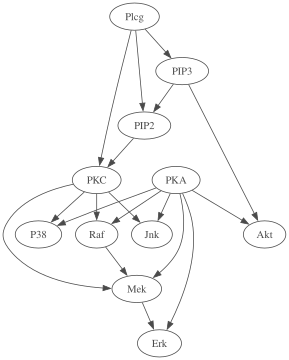

In [6]:
bench.show_golden()

## Best scores (CPDAG)

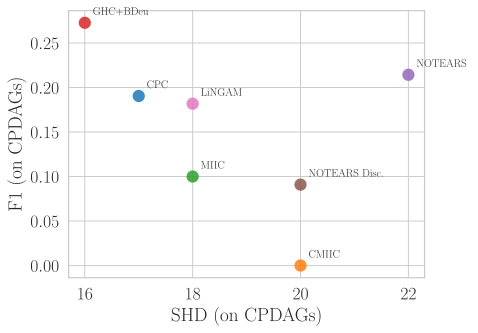

In [7]:
bench.plot_best_scores("cpdag");

## Best scores (Skeleton)

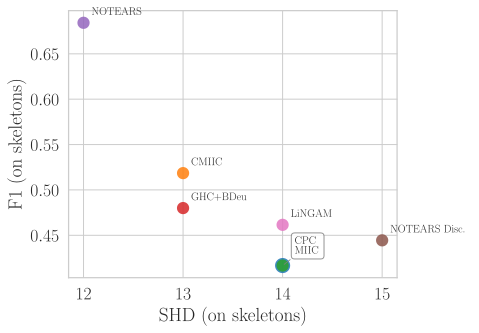

In [8]:
bench.plot_best_scores("skeleton");

## Learned structures

In [9]:
bench.plot_structures()

## Pairwise heatmaps (CPDAG)

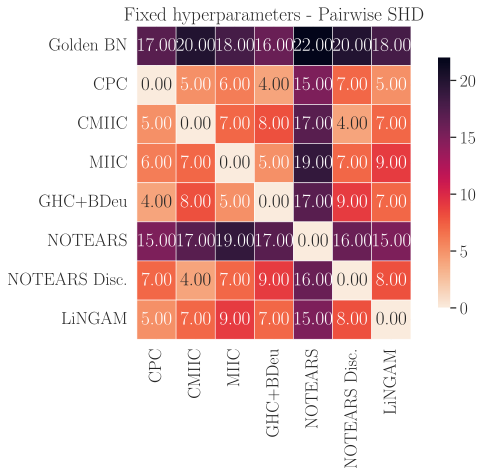

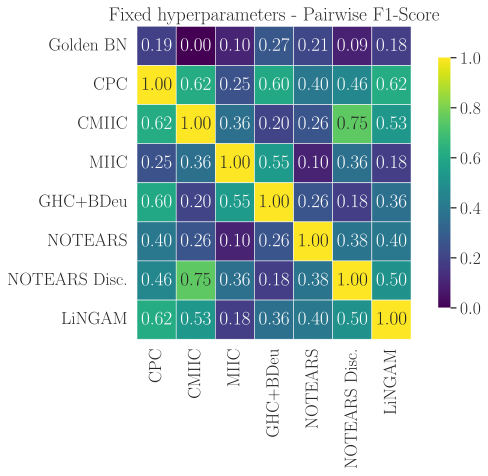

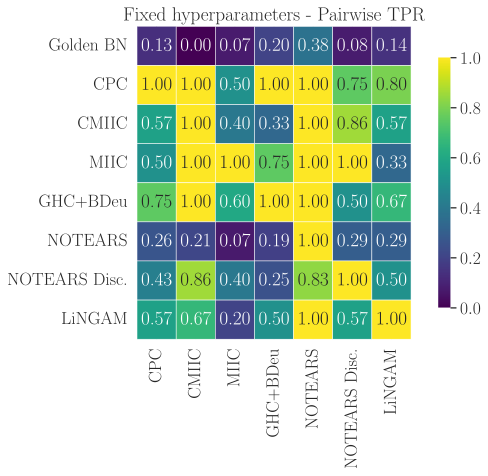

In [10]:
bench.plot_pairwise_heatmaps("cpdag")

## Pairwise heatmaps (Skeleton)

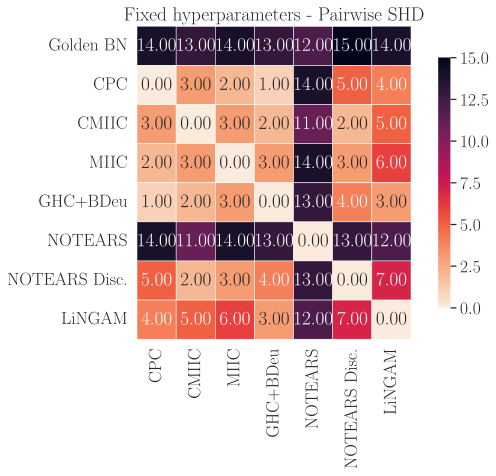

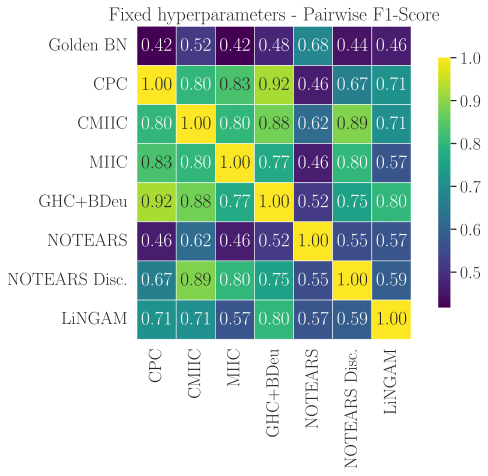

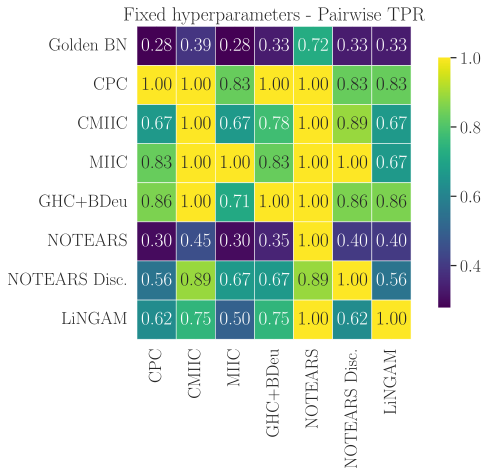

In [11]:
bench.plot_pairwise_heatmaps("skeleton")

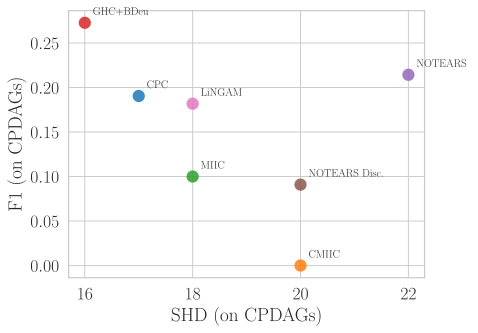

  Saved figures_sachs_august/sachs_shd_f1_cpdags.svg


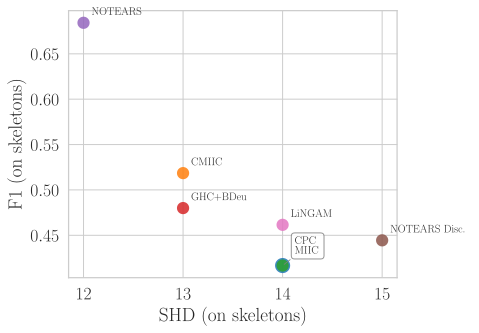

  Saved figures_sachs_august/sachs_shd_f1_skeletons.svg


In [12]:
# Export des figures (nuages SHD/F1, et structures apprises si besoin).
# Sortie dans experiments/gridsearch/figures_sachs_august/ ; la copie vers le
# depot du rapport reste un geste manuel.
SAVE = True

if SAVE:
    from pathlib import Path

    SAVE_DIR = Path("figures_sachs_august")
    SAVE_DIR.mkdir(exist_ok=True)

    for mode, name in [("cpdag", "sachs_shd_f1_cpdags.svg"),
                       ("skeleton", "sachs_shd_f1_skeletons.svg")]:
        fig = bench.plot_best_scores(mode)
        fig.savefig(SAVE_DIR / name, bbox_inches="tight")
        print("  Saved", SAVE_DIR / name)

    # structures apprises (inchangees ici, donc inutile de les reexporter) :
    # bench.plot_structures(save_dir=SAVE_DIR / "structures")